In [3]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
cifar_recon = "C:\\home\\ae_data/landscape_data/cifar/Reconstructions/trainUval/reconstructions_e199.pt"
mnist_recon = "C:\\home\\ae_data/landscape_data/mnist/Reconstructions/trainUval/reconstructions_e199.pt"
emnist_recon = "C:\\home\\ae_data/landscape_data/emnist_letters/Reconstructions/trainUval/reconstructions_e199.pt"

cifar_losses = np.loadtxt("C:\\home\\ae_data/landscape_data/cifar/Losses/trainUval/losses_e199.txt")
mnist_losses = np.loadtxt("C:\\home\\ae_data/landscape_data/mnist/Losses/trainUval/losses_e199.txt")
emnist_losses = np.loadtxt("C:\\home\\ae_data/landscape_data/emnist_letters/Losses/trainUval/losses_e199.txt")

cifar_recon = torch.load(cifar_recon)
mnist_recon = torch.load(mnist_recon)
emnist_recon = torch.load(emnist_recon)

cifar_recon -= torch.amin(cifar_recon, dim=(2,3), keepdim=True)
cifar_recon /= torch.amax(cifar_recon, dim=(2,3), keepdim=True)

mnist_recon -= torch.amin(mnist_recon, dim=(2,3), keepdim=True)
mnist_recon /= torch.amax(mnist_recon, dim=(2,3), keepdim=True)

emnist_recon -= torch.amin(emnist_recon, dim=(2,3), keepdim=True)
emnist_recon /= torch.amax(emnist_recon, dim=(2,3), keepdim=True)

torch.min(cifar_recon), torch.max(cifar_recon), torch.min(mnist_recon), torch.max(mnist_recon), torch.min(emnist_recon), torch.max(emnist_recon)

(tensor(0.), tensor(1.), tensor(0.), tensor(1.), tensor(0.), tensor(1.))

In [7]:
idx = mnist_losses.argmax()
mnist_losses[idx]

np.float64(0.1586001068353653)

In [9]:
from cifar10_loader import make_cifar10_dataloaders, get_cifar10_transforms
from mnist_loader import make_mnist_dataloaders, get_mnist_transforms
from emnist_loader import make_emnist_dataloaders, get_emnist_transforms

_, cifar_tf = get_cifar10_transforms()
cifar_tr, cifar_ts = make_cifar10_dataloaders("../../datasets/cifar/data", batch_size=1, train_transform=cifar_tf, test_transform=cifar_tf)
_, mnist_tf = get_mnist_transforms()
mnist_tr, mnist_ts = make_mnist_dataloaders("../../datasets/mnist/data", batch_size=1, transform=mnist_tf)
_, emnist_tf = get_emnist_transforms()
emnist_tr, emnist_ts = make_emnist_dataloaders("../../datasets/emnist_letters/data", batch_size=1, transform=emnist_tf, variant='letters')

c:\Users\Santripta\miniconda3\envs\llvis\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [10]:
from torch.utils.data import ConcatDataset

cifar = ConcatDataset([cifar_tr.dataset, cifar_ts.dataset])
mnist = ConcatDataset([mnist_tr.dataset, mnist_ts.dataset])
emnist = ConcatDataset([emnist_tr.dataset, emnist_ts.dataset])

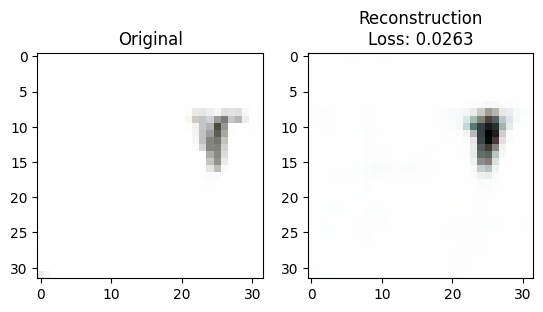

In [24]:
def cf_show(idx):
    img = cifar[idx]["image"]
    recon = cifar_recon[idx]

    fig, axs = plt.subplots(1,2)
    axs[0].imshow(np.transpose(img.numpy(), (1,2,0)))
    axs[0].set_title("Original")
    axs[1].imshow(np.transpose(recon.numpy(), (1,2,0)))
    loss = cifar_losses[idx]
    axs[1].set_title(f"Reconstruction\nLoss: {loss:.4f}")
    plt.show()

idx = cifar_losses.argmin()
cifar[idx]["label"]
cf_show(cifar_losses.argmin())

In [8]:
def mn_show(idx):
    img = mnist[idx]["image"].squeeze(0)
    recon = mnist_recon[idx].squeeze(0)

    fig, axs = plt.subplots(1,2)
    axs[0].imshow(np.transpose(img.numpy(), (1,2,0)), cmap='gray')
    axs[0].set_title("Original")
    axs[1].imshow(np.transpose(recon.numpy(), (1,2,0)), cmap='gray')
    loss = mnist_losses[idx]
    axs[1].set_title(f"Reconstruction\nLoss: {loss:.4f}")
    plt.show()

mn_show(65682)

NameError: name 'mnist' is not defined

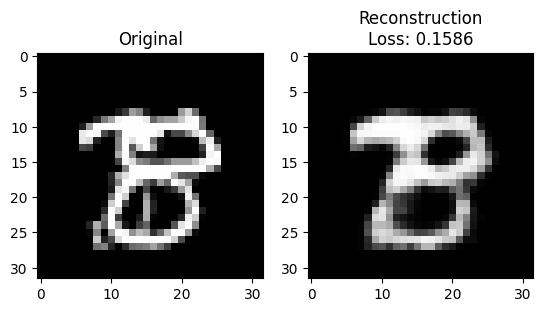

In [11]:
mn_show(idx)

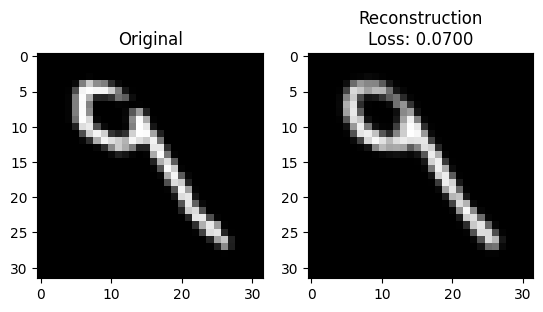

In [281]:
def emn_show(idx):
    img = emnist[idx]["image"].squeeze(0)
    recon = emnist_recon[idx].squeeze(0)

    fig, axs = plt.subplots(1,2)
    axs[0].imshow(np.transpose(img.numpy(), (1,2,0)), cmap='gray')
    axs[0].set_title("Original")
    axs[1].imshow(np.transpose(recon.numpy(), (1,2,0)), cmap='gray')
    loss = emnist_losses[idx]
    axs[1].set_title(f"Reconstruction\nLoss: {loss:.4f}")
    plt.show()

emn_show(123456)